# GPU-Accelerated UMAP Analysis for 14 Million Sample Dataset

This notebook provides a high-performance UMAP implementation with GPU acceleration for large-scale dimensionality reduction analysis of test scenarios.

**Author:** AI Assistant  
**Description:** Interactive analysis of MIRT model scenario factors using UMAP

## Features:
- GPU-accelerated UMAP with CPU fallback
- 2D and 3D visualizations
- Hyperparameter optimization
- Large dataset handling (14M+ samples)

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import warnings
import time
import sys
import os

# Add plotly for interactive plots
try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    print("✅ Plotly loaded for interactive plots")
    PLOTLY_AVAILABLE = True
except ImportError:
    print("⚠️  Plotly not available. Install with: pip install plotly")
    PLOTLY_AVAILABLE = False

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully")

✅ Plotly loaded for interactive plots
✅ Libraries imported successfully


## GPU Dependencies Setup

Run the following cell to check and install GPU dependencies if needed.

In [2]:
def install_gpu_dependencies():
    """
    Install GPU-accelerated UMAP dependencies
    """
    print("Installing GPU dependencies...")
    print("For RAPIDS cuML (recommended for NVIDIA GPUs):")
    print("conda install -c rapidsai -c conda-forge cuml=23.12 python=3.10 cudatoolkit=11.8")
    print("\nFor CPU fallback:")
    print("pip install umap-learn[plot]")
    print("\nFor interactive plotting:")  
    print("pip install plotly bokeh")

def setup_umap_gpu():
    """
    Setup UMAP with GPU acceleration, with CPU fallback
    """
    try:
        # Try GPU-accelerated UMAP first (RAPIDS cuML)
        print("Attempting to load GPU-accelerated UMAP (cuML)...")
        from cuml.manifold import UMAP as cuUMAP
        print("✅ GPU-accelerated UMAP (cuML) loaded successfully!")
        return cuUMAP, "GPU"
    except ImportError:
        try:
            # Fallback to CPU UMAP
            print("GPU UMAP not available, falling back to CPU UMAP...")
            from umap import UMAP
            print("✅ CPU UMAP loaded successfully!")
            return UMAP, "CPU"
        except ImportError:
            print("❌ Neither GPU nor CPU UMAP available!")
            print("Please install: pip install umap-learn")
            return None, None

# Setup UMAP
umap_class, device = setup_umap_gpu()

if umap_class is None:
    print("❌ UMAP not available. Install dependencies:")
    install_gpu_dependencies()

Attempting to load GPU-accelerated UMAP (cuML)...
✅ GPU-accelerated UMAP (cuML) loaded successfully!
✅ GPU-accelerated UMAP (cuML) loaded successfully!


## Configuration

Set up paths and parameters for the analysis.

In [3]:
# Configuration
data_path = "../data/resmat.pkl"
result_path = "../result/"

# Ensure result directory exists
os.makedirs(result_path, exist_ok=True)

print(f"📁 Data path: {data_path}")
print(f"📁 Result path: {result_path}")
print(f"🖥️  Device: {device}")

📁 Data path: ../data/resmat.pkl
📁 Result path: ../result/
🖥️  Device: GPU


## Data Loading

Load the scenario factors and labels from the MIRT model.

In [4]:
# Load data for UMAP analysis
print("Loading data...")

# Load scenario factors (equivalent to your a_for_z_numpy)
try:
    scenario_factors = np.load(f"{result_path}scenario_factors.npy")
    print(f"Loaded existing scenario factors: {scenario_factors.shape}")
except FileNotFoundError:
    print("Scenario factors not found, loading from MIRT model...")
    # If you haven't saved scenario_factors.npy yet, load from your MIRT model
    sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official')
    from load_params import load_and_rotate
    _, scenario_factors, _ = load_and_rotate('./output/mirt_model_k19.pt')
    np.save(f"{result_path}scenario_factors.npy", scenario_factors)
    print(f"Loaded and saved scenario factors: {scenario_factors.shape}")

# Load scenario labels
resmat = pd.read_pickle(data_path)
balanced_resmat = resmat.columns.to_frame()
scenario_labels = balanced_resmat['scenario'].values

print(f"Data loaded: {scenario_factors.shape[0]:,} samples, {scenario_factors.shape[1]} dimensions")
print(f"Unique scenarios: {len(np.unique(scenario_labels))}")

Loading data...


Loaded existing scenario factors: (78712, 19)
Data loaded: 78,712 samples, 19 dimensions
Unique scenarios: 22
Data loaded: 78,712 samples, 19 dimensions
Unique scenarios: 22


In [5]:
# Run 2D UMAP with optimized parameters for large datasets
print(f"\n🚀 Running 2D UMAP on {device}...")

# Parameters for 2D UMAP
n_neighbors_2d = 50      # Larger for smoother embeddings
min_dist_2d = 0.1        # Good balance of local/global structure
metric_2d = 'euclidean'  # Fast and effective
spread_2d = 1.5          # Slightly more spread for better separation
random_state = 42

print(f"Parameters: n_neighbors={n_neighbors_2d}, min_dist={min_dist_2d}, metric={metric_2d}")

start_time = time.time()

if device == "GPU":
    # GPU-optimized parameters
    umap_model_2d = umap_class(
        n_components=2,
        n_neighbors=n_neighbors_2d,
        min_dist=min_dist_2d,
        metric=metric_2d,
        spread=spread_2d,
        random_state=random_state,
        verbose=True
    )
else:
    # CPU parameters with performance optimizations
    umap_model_2d = umap_class(
        n_components=2,
        n_neighbors=n_neighbors_2d,
        min_dist=min_dist_2d,
        metric=metric_2d,
        spread=spread_2d,
        random_state=random_state,
        verbose=True,
        n_jobs=-1,  # Use all CPU cores
        low_memory=False  # Use more memory for speed
    )

umap_2d_result = umap_model_2d.fit_transform(scenario_factors)

end_time = time.time()
print(f"✅ 2D UMAP completed in {end_time - start_time:.2f} seconds")
print(f"Result shape: {umap_2d_result.shape}")

# Save results
np.save(f"{result_path}umap_2d.npy", umap_2d_result)
print(f"Saved to {result_path}umap_2d.npy")


🚀 Running 2D UMAP on GPU...
Parameters: n_neighbors=50, min_dist=0.1, metric=euclidean
[2025-09-05 09:33:35.093] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-09-05 09:33:35.372] [CUML] [debug] Computing KNN Graph
[2025-09-05 09:33:35.504] [CUML] [debug] Computing fuzzy simplicial set
[2025-09-05 09:33:35.372] [CUML] [debug] Computing KNN Graph
[2025-09-05 09:33:35.504] [CUML] [debug] Computing fuzzy simplicial set
✅ 2D UMAP completed in 0.97 seconds
Result shape: (78712, 2)
Saved to ../result/umap_2d.npy
✅ 2D UMAP completed in 0.97 seconds
Result shape: (78712, 2)
Saved to ../result/umap_2d.npy


In [6]:
# Run 3D UMAP for landscape visualization
print(f"\n🚀 Running 3D UMAP on {device}...")

# Parameters for 3D UMAP
n_neighbors_3d = 50
min_dist_3d = 0.1
metric_3d = 'euclidean'
spread_3d = 1.5

print(f"Parameters: n_neighbors={n_neighbors_3d}, min_dist={min_dist_3d}, metric={metric_3d}")

start_time = time.time()

if device == "GPU":
    umap_model_3d = umap_class(
        n_components=3,
        n_neighbors=n_neighbors_3d,
        min_dist=min_dist_3d,
        metric=metric_3d,
        spread=spread_3d,
        random_state=random_state,
        verbose=True
    )
else:
    umap_model_3d = umap_class(
        n_components=3,
        n_neighbors=n_neighbors_3d,
        min_dist=min_dist_3d,
        metric=metric_3d,
        spread=spread_3d,
        random_state=random_state,
        verbose=True,
        n_jobs=-1,
        low_memory=False
    )

umap_3d_result = umap_model_3d.fit_transform(scenario_factors)

end_time = time.time()
print(f"✅ 3D UMAP completed in {end_time - start_time:.2f} seconds")
print(f"Result shape: {umap_3d_result.shape}")

# Save results
np.save(f"{result_path}umap_3d.npy", umap_3d_result)
print(f"Saved to {result_path}umap_3d.npy")


🚀 Running 3D UMAP on GPU...
Parameters: n_neighbors=50, min_dist=0.1, metric=euclidean
[2025-09-05 09:33:36.220] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-09-05 09:33:36.226] [CUML] [debug] Computing KNN Graph
[2025-09-05 09:33:36.343] [CUML] [debug] Computing fuzzy simplicial set
[2025-09-05 09:33:36.343] [CUML] [debug] Computing fuzzy simplicial set
✅ 3D UMAP completed in 0.61 seconds
Result shape: (78712, 3)
Saved to ../result/umap_3d.npy
✅ 3D UMAP completed in 0.61 seconds
Result shape: (78712, 3)
Saved to ../result/umap_3d.npy



📊 Creating 2D UMAP visualization...


Saved to ../result/umap_2d_highlighted.pdf


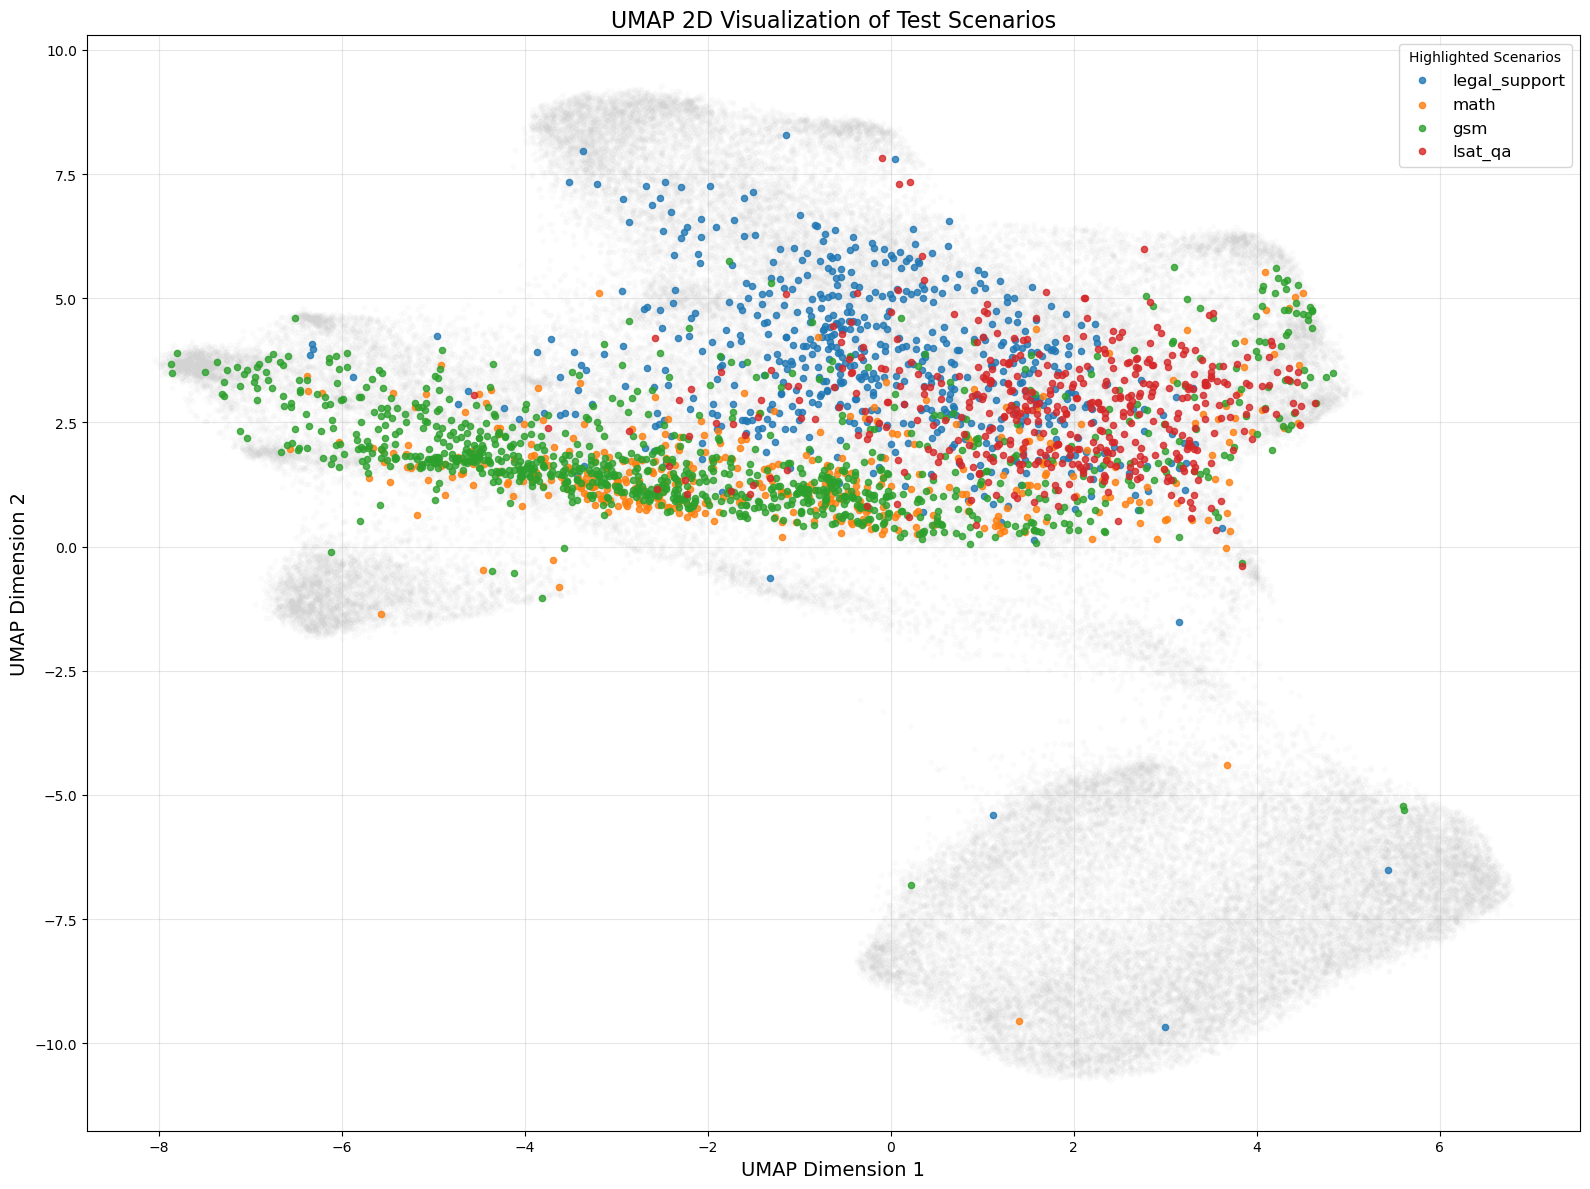

In [7]:
# Create 2D UMAP visualization with highlighted scenarios
print("\n📊 Creating 2D UMAP visualization...")

# Configuration for highlighting
labels_to_highlight = ['legal_support', 'math', 'gsm', 'lsat_qa']
figsize = (16, 12)
save_name_2d = "umap_2d_highlighted.pdf"

# Setup colors
default_color = 'lightgrey'
colors = plt.colormaps.get_cmap('tab10')
color_map = {label: colors(i) for i, label in enumerate(labels_to_highlight)}

plt.figure(figsize=figsize)

# Plot non-highlighted points first
non_highlighted_mask = ~np.isin(scenario_labels, labels_to_highlight)
if np.any(non_highlighted_mask):
    plt.scatter(umap_2d_result[non_highlighted_mask, 0], 
               umap_2d_result[non_highlighted_mask, 1], 
               c=default_color, alpha=0.05, s=10, zorder=1)

# Plot highlighted points
for label in labels_to_highlight:
    mask = scenario_labels == label
    if np.any(mask):
        plt.scatter(umap_2d_result[mask, 0], umap_2d_result[mask, 1], 
                   c=color_map[label], alpha=0.8, s=20, zorder=2, label=label)

plt.title('UMAP 2D Visualization of Test Scenarios', fontsize=16)
plt.xlabel('UMAP Dimension 1', fontsize=14)
plt.ylabel('UMAP Dimension 2', fontsize=14)
plt.legend(title='Highlighted Scenarios', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{result_path}{save_name_2d}", dpi=300, bbox_inches='tight')
print(f"Saved to {result_path}{save_name_2d}")
plt.show()

In [29]:
# Create interactive 3D UMAP landscape visualization
print("\n📊 Creating interactive 3D UMAP landscape visualization...")

if PLOTLY_AVAILABLE:
    # Setup colors for interactive plot
    colors_plotly = px.colors.qualitative.Set1
    color_map_plotly = {label: colors_plotly[i % len(colors_plotly)] for i, label in enumerate(labels_to_highlight)}
    
    # Create the figure
    fig = go.Figure()
    
    # Plot non-highlighted points first (background)
    non_highlighted_mask = ~np.isin(scenario_labels, labels_to_highlight)
    if np.any(non_highlighted_mask):
        fig.add_trace(go.Scatter3d(
            x=umap_3d_result[non_highlighted_mask, 0],
            y=umap_3d_result[non_highlighted_mask, 1],
            z=umap_3d_result[non_highlighted_mask, 2],
            mode='markers',
            marker=dict(
                size=2,
                color='lightgrey',
                opacity=0.3
            ),
            name='Other scenarios',
            hovertemplate='<b>Other scenario</b><br>' +
                         'X: %{x:.2f}<br>' +
                         'Y: %{y:.2f}<br>' +
                         'Z: %{z:.2f}<br>' +
                         '<extra></extra>',
            showlegend=True
        ))
    
    # Plot highlighted points
    for label in labels_to_highlight:
        mask = scenario_labels == label
        if np.any(mask):
            fig.add_trace(go.Scatter3d(
                x=umap_3d_result[mask, 0],
                y=umap_3d_result[mask, 1],
                z=umap_3d_result[mask, 2],
                mode='markers',
                marker=dict(
                    size=4,
                    color=color_map_plotly[label],
                    opacity=0.8,
                    line=dict(
                        color='black',
                        width=0.5
                    )
                ),
                name=label,
                hovertemplate=f'<b>{label}</b><br>' +
                             'X: %{x:.2f}<br>' +
                             'Y: %{y:.2f}<br>' +
                             'Z: %{z:.2f}<br>' +
                             '<extra></extra>',
                showlegend=True
            ))
    
    # Update layout for better visualization
    fig.update_layout(
        title={
            'text': '3D UMAP Landscape of Test Scenarios (Interactive)',
            'x': 0.5,
            'font': {'size': 16}
        },
        scene=dict(
            xaxis_title='UMAP Dimension 1',
            yaxis_title='UMAP Dimension 2',
            zaxis_title='UMAP Dimension 3',
             # --- THIS IS THE EDITED PART ---
            # Paste the camera dictionary you extracted here to set a default view.
            camera=dict(
                up=dict(x=0, y=0, z=1),
                center=dict(x=0, y=0, z=0),
                eye=dict(x=1.8, y=-1.2, z=0.9) # <-- REPLACE THESE VALUES
            ),
            bgcolor='white'
        ),
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01,
            bgcolor="rgba(255,255,255,0.8)",
            bordercolor="Black",
            borderwidth=1
        ),
        width=1000,
        height=800,
        margin=dict(r=20, b=10, l=10, t=40)
    )
    
    # Save interactive plot
    save_name_interactive = "umap_3d_interactive.html"
    fig.write_html(f"{result_path}{save_name_interactive}")
    print(f"Saved interactive plot to {result_path}{save_name_interactive}")
    
    # Display the plot
    fig.show()
    
else:
    print("❌ Plotly not available. Skipping interactive plot.")


📊 Creating interactive 3D UMAP landscape visualization...
Saved interactive plot to ../result/umap_3d_interactive.html



📊 Creating static 3D UMAP landscape visualization...
Saved to ../result/umap_3d_landscape.pdf
Saved to ../result/umap_3d_landscape.pdf


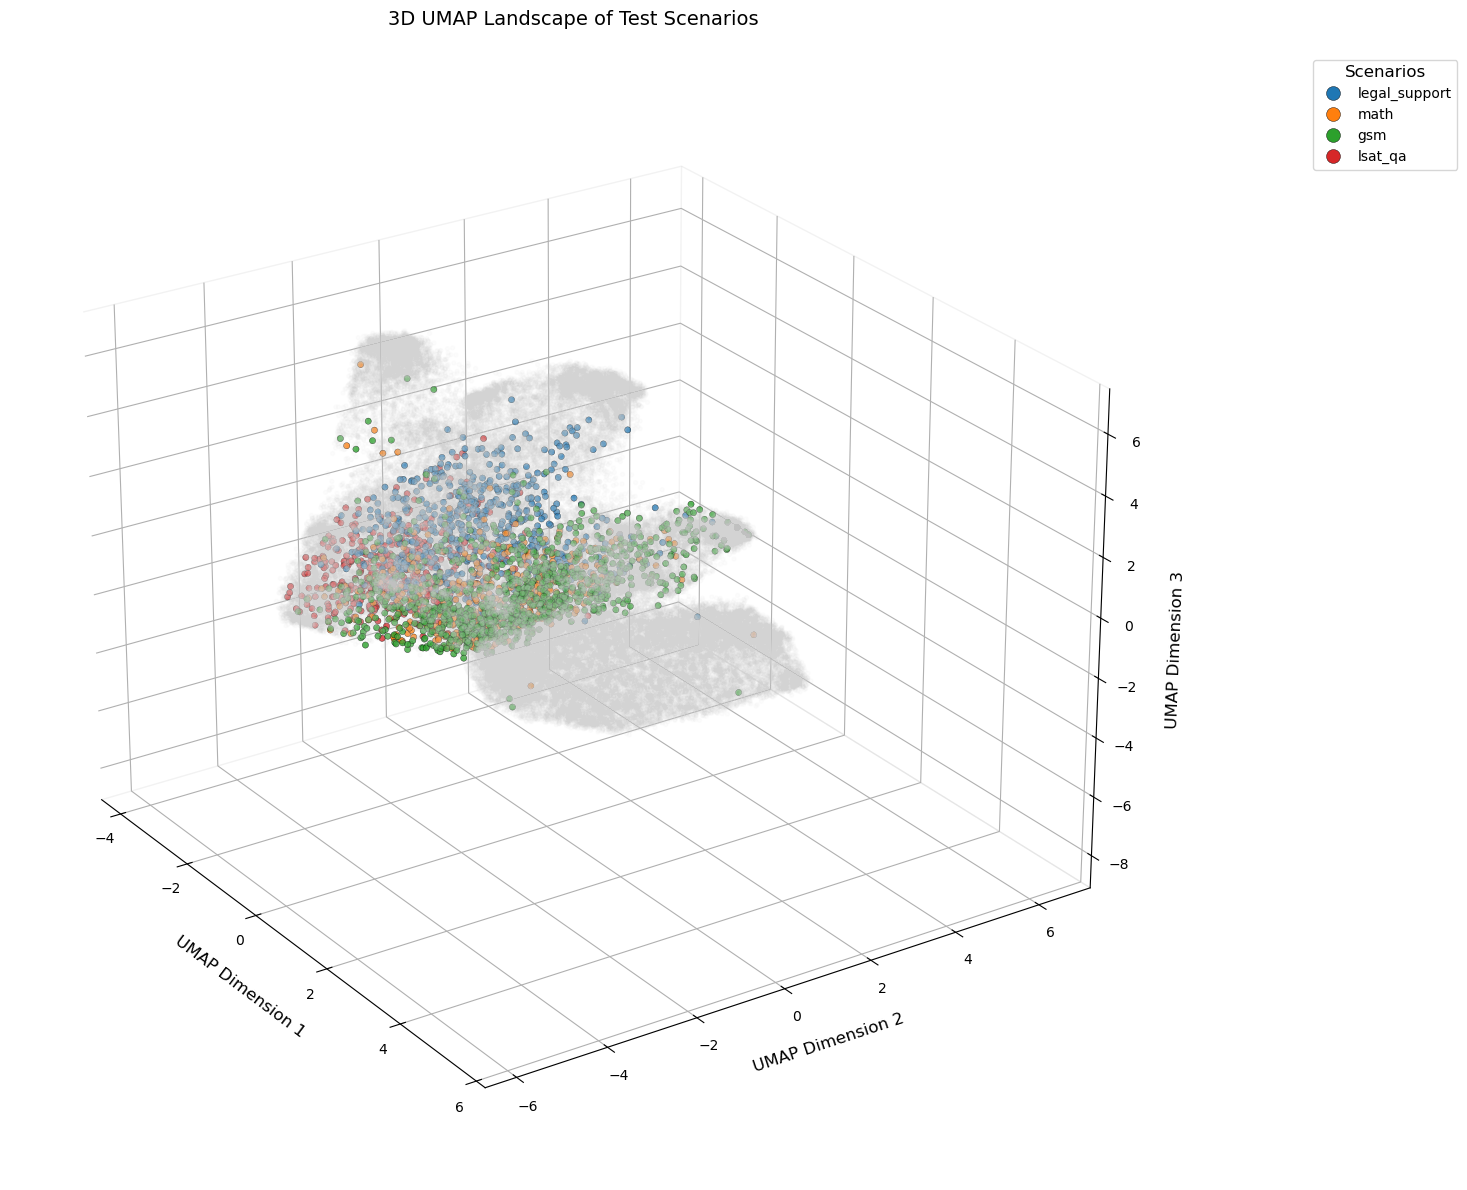

In [32]:
# Create static 3D UMAP landscape visualization (matplotlib fallback)
print("\n📊 Creating static 3D UMAP landscape visualization...")

# Setup colors for static plot
default_color = 'lightgrey'
colors_static = plt.colormaps.get_cmap('tab10')
color_map_static = {label: colors_static(i) for i, label in enumerate(labels_to_highlight)}

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot non-highlighted points
non_highlighted_mask = ~np.isin(scenario_labels, labels_to_highlight)
if np.any(non_highlighted_mask):
    ax.scatter(umap_3d_result[non_highlighted_mask, 0], 
              umap_3d_result[non_highlighted_mask, 1], 
              umap_3d_result[non_highlighted_mask, 2], 
              c=default_color, alpha=0.05, s=8, depthshade=True)

# Plot highlighted points
handles = []
for label in labels_to_highlight:
    mask = scenario_labels == label
    if np.any(mask):
        ax.scatter(umap_3d_result[mask, 0], umap_3d_result[mask, 1], 
                  umap_3d_result[mask, 2], c=color_map_static[label], 
                  alpha=0.8, s=20, depthshade=True, label=label, 
                  edgecolors='black', linewidth=0.3)
        
        handles.append(plt.Line2D([0], [0], marker='o', color='w', label=label,
                                markerfacecolor=color_map_static[label], markersize=10,
                                markeredgecolor='black', markeredgewidth=0.3))

# Styling
ax.set_xlabel('UMAP Dimension 1', fontsize=12, labelpad=10)
ax.set_ylabel('UMAP Dimension 2', fontsize=12, labelpad=10) 
ax.set_zlabel('UMAP Dimension 3', fontsize=12, labelpad=10)
ax.set_title('3D UMAP Landscape of Test Scenarios', fontsize=14, pad=20)
# Convert plotly camera (eye=dict(x=1.8, y=-1.2, z=0.9)) to matplotlib view_init
# Plotly eye coordinates roughly translate to: elev ≈ arcsin(z/r), azim ≈ arctan2(y,x) in degrees
ax.view_init(elev=25, azim=-34)
ax.grid(True, alpha=0.3)

# Pane styling
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('gray')
ax.yaxis.pane.set_edgecolor('gray')
ax.zaxis.pane.set_edgecolor('gray')
ax.xaxis.pane.set_alpha(0.1)
ax.yaxis.pane.set_alpha(0.1)
ax.zaxis.pane.set_alpha(0.1)

ax.legend(handles=handles, title='Scenarios', bbox_to_anchor=(1.15, 1), 
          loc='upper left', fontsize=10, title_fontsize=12)

plt.tight_layout()
save_name_static = "umap_3d_landscape.pdf"
plt.savefig(f"{result_path}{save_name_static}", bbox_inches='tight')
print(f"Saved to {result_path}{save_name_static}")
plt.show()

In [10]:
# Optional: Hyperparameter search for UMAP parameters
# Uncomment and run this cell if you want to find optimal parameters

# print("\n🔍 Starting hyperparameter search...")
# print("This will test different parameter combinations...")

# param_grid = {
#     'n_neighbors': [15, 30, 50, 100],
#     'min_dist': [0.05, 0.1, 0.3, 0.5],
#     'metric': ['euclidean', 'cosine', 'manhattan']
# }

# results = []
# total_combinations = len(param_grid['n_neighbors']) * len(param_grid['min_dist']) * len(param_grid['metric'])

# for i, n_neighbors in enumerate(param_grid['n_neighbors']):
#     for j, min_dist in enumerate(param_grid['min_dist']):
#         for k, metric in enumerate(param_grid['metric']):
#             combo_num = i * len(param_grid['min_dist']) * len(param_grid['metric']) + j * len(param_grid['metric']) + k + 1
#             print(f"Testing combination {combo_num}/{total_combinations}: n_neighbors={n_neighbors}, min_dist={min_dist}, metric={metric}")
            
#             start_time = time.time()
            
#             try:
#                 if device == "GPU":
#                     umap_model = umap_class(
#                         n_components=2,
#                         n_neighbors=n_neighbors,
#                         min_dist=min_dist,
#                         metric=metric,
#                         random_state=42,
#                         verbose=False
#                     )
#                 else:
#                     umap_model = umap_class(
#                         n_components=2,
#                         n_neighbors=n_neighbors,
#                         min_dist=min_dist,
#                         metric=metric,
#                         random_state=42,
#                         verbose=False,
#                         n_jobs=-1
#                     )
                
#                 # Use a subset for hyperparameter search to save time
#                 subset_size = min(10000, len(scenario_factors))
#                 subset_indices = np.random.choice(len(scenario_factors), subset_size, replace=False)
#                 subset_data = scenario_factors[subset_indices]
                
#                 embedding = umap_model.fit_transform(subset_data)
#                 end_time = time.time()
                
#                 results.append({
#                     'n_neighbors': n_neighbors,
#                     'min_dist': min_dist,
#                     'metric': metric,
#                     'time': end_time - start_time,
#                     'embedding_std': np.std(embedding),
#                     'embedding_range': np.ptp(embedding)
#                 })
                
#                 print(f"  ✅ Completed in {end_time - start_time:.2f}s")
                
#             except Exception as e:
#                 print(f"  ❌ Failed: {e}")
#                 continue

# # Save results
# results_df = pd.DataFrame(results)
# results_df.to_csv(f"{result_path}umap_hyperparameter_results.csv", index=False)
# print(f"\n📊 Hyperparameter search complete! Results saved to {result_path}umap_hyperparameter_results.csv")

# # Show best parameters based on embedding quality
# if len(results_df) > 0:
#     best_params = results_df.loc[results_df['embedding_std'].idxmax()]
#     print("\n🏆 Best parameters (highest embedding standard deviation):")
#     print(f"n_neighbors: {best_params['n_neighbors']}")
#     print(f"min_dist: {best_params['min_dist']}")
#     print(f"metric: {best_params['metric']}")
#     print(f"Time: {best_params['time']:.2f}s")

print("💡 Hyperparameter search is commented out to save time.")
print("Uncomment the code above if you want to find optimal parameters.")

💡 Hyperparameter search is commented out to save time.
Uncomment the code above if you want to find optimal parameters.


In [11]:
# Optional: Create a combined interactive view with both 2D and 3D plots
# Uncomment and run this cell to create a side-by-side comparison

# if PLOTLY_AVAILABLE:
#     print("\n📊 Creating combined 2D and 3D interactive view...")
    
#     # Create subplots
#     fig_combined = make_subplots(
#         rows=1, cols=2,
#         specs=[[{"type": "scatter"}, {"type": "scatter3d"}]],
#         subplot_titles=("2D UMAP", "3D UMAP"),
#         horizontal_spacing=0.1
#     )
    
#     colors_combined = px.colors.qualitative.Set1
#     color_map_combined = {label: colors_combined[i % len(colors_combined)] for i, label in enumerate(labels_to_highlight)}
    
#     # Add 2D plot
#     non_highlighted_mask = ~np.isin(scenario_labels, labels_to_highlight)
#     if np.any(non_highlighted_mask):
#         fig_combined.add_trace(
#             go.Scatter(
#                 x=umap_2d_result[non_highlighted_mask, 0],
#                 y=umap_2d_result[non_highlighted_mask, 1],
#                 mode='markers',
#                 marker=dict(size=3, color='lightgrey', opacity=0.3),
#                 name='Other (2D)',
#                 showlegend=False
#             ), row=1, col=1
#         )
    
#     for label in labels_to_highlight:
#         mask = scenario_labels == label
#         if np.any(mask):
#             fig_combined.add_trace(
#                 go.Scatter(
#                     x=umap_2d_result[mask, 0],
#                     y=umap_2d_result[mask, 1],
#                     mode='markers',
#                     marker=dict(size=4, color=color_map_combined[label], opacity=0.8),
#                     name=f'{label} (2D)',
#                     legendgroup=label
#                 ), row=1, col=1
#             )
    
#     # Add 3D plot
#     if np.any(non_highlighted_mask):
#         fig_combined.add_trace(
#             go.Scatter3d(
#                 x=umap_3d_result[non_highlighted_mask, 0],
#                 y=umap_3d_result[non_highlighted_mask, 1],
#                 z=umap_3d_result[non_highlighted_mask, 2],
#                 mode='markers',
#                 marker=dict(size=2, color='lightgrey', opacity=0.3),
#                 name='Other (3D)',
#                 showlegend=False
#             ), row=1, col=2
#         )
    
#     for label in labels_to_highlight:
#         mask = scenario_labels == label
#         if np.any(mask):
#             fig_combined.add_trace(
#                 go.Scatter3d(
#                     x=umap_3d_result[mask, 0],
#                     y=umap_3d_result[mask, 1],
#                     z=umap_3d_result[mask, 2],
#                     mode='markers',
#                     marker=dict(size=3, color=color_map_combined[label], opacity=0.8),
#                     name=f'{label} (3D)',
#                     legendgroup=label
#                 ), row=1, col=2
#             )
    
#     fig_combined.update_layout(
#         title="UMAP Analysis: 2D vs 3D Comparison",
#         width=1400,
#         height=700
#     )
    
#     fig_combined.write_html(f"{result_path}umap_comparison_interactive.html")
#     print(f"Saved comparison view to {result_path}umap_comparison_interactive.html")
#     fig_combined.show()

# else:
#     print("❌ Plotly not available for combined view")

print("💡 Combined view is commented out to save space.")
print("Uncomment the code above to create a side-by-side 2D/3D comparison.")

💡 Combined view is commented out to save space.
Uncomment the code above to create a side-by-side 2D/3D comparison.


In [12]:
# Analysis complete - summary of results
print("✅ Analysis complete!")
print(f"Results saved in: {result_path}")
print("\nFiles created:")

files_to_check = [
    'umap_2d.npy', 
    'umap_3d.npy', 
    'scenario_factors.npy',
    'umap_2d_highlighted.pdf',
    'umap_3d_landscape.pdf'
]

if PLOTLY_AVAILABLE:
    files_to_check.append('umap_3d_interactive.html')

for file in files_to_check:
    if os.path.exists(f"{result_path}{file}"):
        print(f"✅ {file}")
    else:
        print(f"❌ {file} (not created)")

print(f"\n📊 UMAP Results Summary:")
print(f"   2D embedding shape: {umap_2d_result.shape}")
print(f"   3D embedding shape: {umap_3d_result.shape}")
print(f"   Total scenarios: {len(scenario_labels)}")
print(f"   Highlighted scenarios: {labels_to_highlight}")
print(f"   Device used: {device}")

✅ Analysis complete!
Results saved in: ../result/

Files created:
✅ umap_2d.npy
✅ umap_3d.npy
✅ scenario_factors.npy
✅ umap_2d_highlighted.pdf
✅ umap_3d_landscape.pdf
✅ umap_3d_interactive.html

📊 UMAP Results Summary:
   2D embedding shape: (78712, 2)
   3D embedding shape: (78712, 3)
   Total scenarios: 78712
   Highlighted scenarios: ['legal_support', 'math', 'gsm', 'lsat_qa']
   Device used: GPU
